In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(123)
np.random.seed(123)

# -----------------------------
# Simulation settings
# -----------------------------
Nsub = 10
K = 2
D = 5
sigma_obs = 0.2

lambda_true = np.array([0.5, 1.0])
theta_true = np.array([0.0, 1.0])
sigma_true = np.array([0.3, 0.4])

W_true = np.array([
    [1.0, 0.5],
    [0.3, 1.2],
    [0.0, 0.8],
    [1.0, -0.5],
    [0.2, 0.7]
])

y_list, t_list, x_list = [], [], []

for i in range(Nsub):
    T_i = np.random.randint(5, 11)
    dt_i = np.random.uniform(0.5, 1.5, size=T_i - 1)
    t_i = np.concatenate([[0.0], np.cumsum(dt_i)])

    x_i = np.zeros((T_i, K))
    x_i[0] = np.random.normal(theta_true, sigma_true)

    for n in range(1, T_i):
        phi = np.exp(-lambda_true * (t_i[n] - t_i[n - 1]))
        ou_sd = sigma_true * np.sqrt((1 - phi ** 2) / (2 * lambda_true))
        mu = theta_true + phi * (x_i[n - 1] - theta_true)
        x_i[n] = np.random.normal(mu, ou_sd)

    y_i = x_i @ W_true.T + np.random.normal(0, sigma_obs, size=(T_i, D))

    x_list.append(x_i)
    y_list.append(y_i)
    t_list.append(t_i)


In [2]:
import torch.nn as nn

class LatentODE_NMF(nn.Module):
    def __init__(self, D, K, Nsub):
        super().__init__()
        self.Lambda = nn.Parameter(torch.randn(D, K) * 0.1)
        self.Theta = nn.Parameter(torch.randn(K, K) * 0.05)
        self.f0 = nn.Parameter(torch.randn(Nsub, K))
        self.log_sigma2 = nn.Parameter(torch.tensor(0.0))

    def latent_traj(self, f0, t):
        traj = []
        for ti in t:
            A = torch.matrix_exp(self.Theta * ti)
            traj.append(A @ f0)
        return torch.stack(traj)

    def forward(self, y_list, t_list):
        sigma2 = torch.exp(self.log_sigma2)
        loss = 0.0

        for i, (y, t) in enumerate(zip(y_list, t_list)):
            f = self.latent_traj(self.f0[i], t)
            y_hat = f @ self.Lambda.T
            loss += ((y - y_hat) ** 2).sum() / (2 * sigma2)
            loss += 0.5 * y.numel() * torch.log(sigma2)

        # regularization
        loss += 1e-3 * self.Theta.pow(2).sum()
        loss += 1e-3 * self.f0.pow(2).sum()
        return loss


In [3]:
model = LatentODE_NMF(D, K, Nsub)
opt = torch.optim.Adam(model.parameters(), lr=1e-2)

y_torch = [torch.tensor(y, dtype=torch.float32) for y in y_list]
t_torch = [torch.tensor(t, dtype=torch.float32) for t in t_list]

for epoch in range(2000):
    opt.zero_grad()
    loss = model(y_torch, t_torch)
    loss.backward()
    opt.step()

    if epoch % 200 == 0:
        print(f"Epoch {epoch}, loss={loss.item():.2f}")


Epoch 0, loss=153.62
Epoch 200, loss=-255.46
Epoch 400, loss=-267.60
Epoch 600, loss=-267.66
Epoch 800, loss=-267.60
Epoch 1000, loss=-267.67
Epoch 1200, loss=-267.67
Epoch 1400, loss=-267.67
Epoch 1600, loss=-267.66
Epoch 1800, loss=-267.67


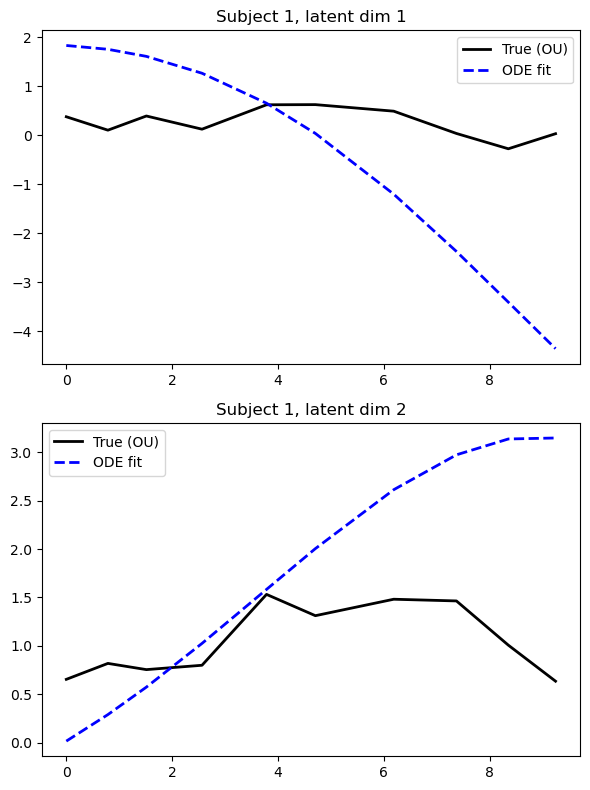

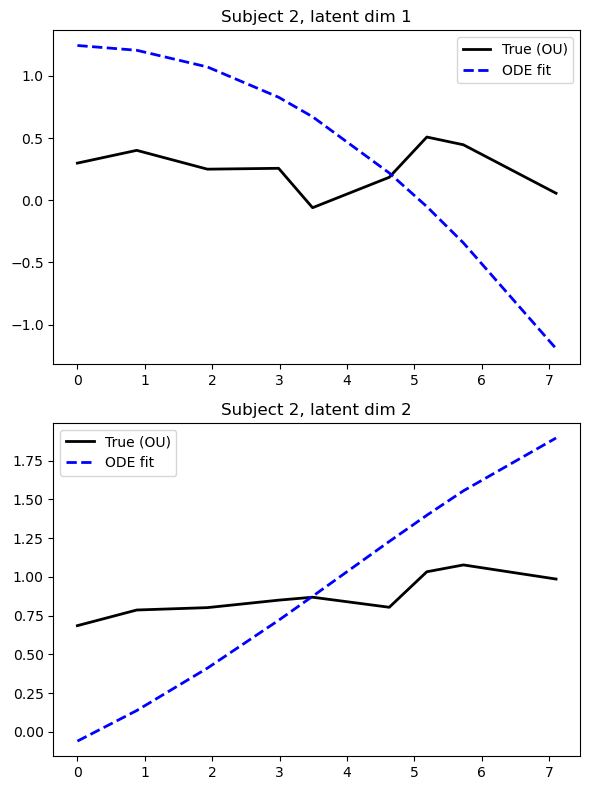

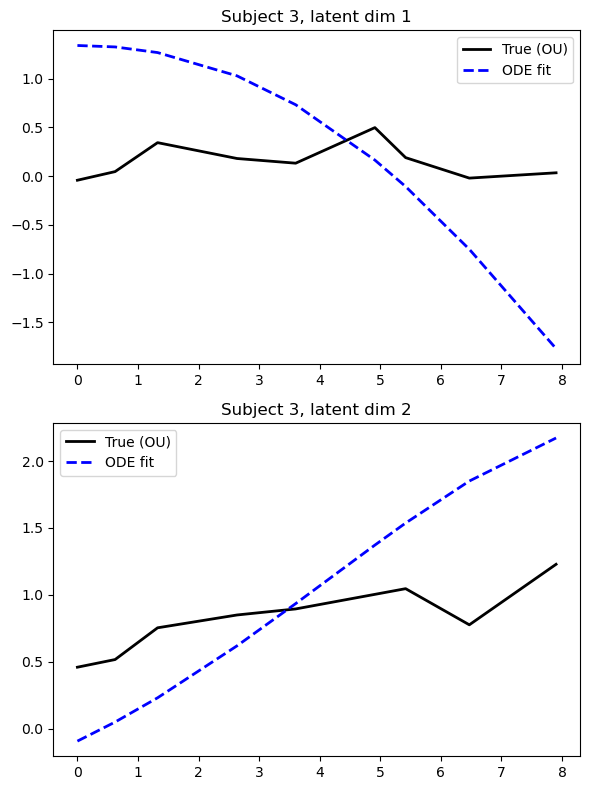

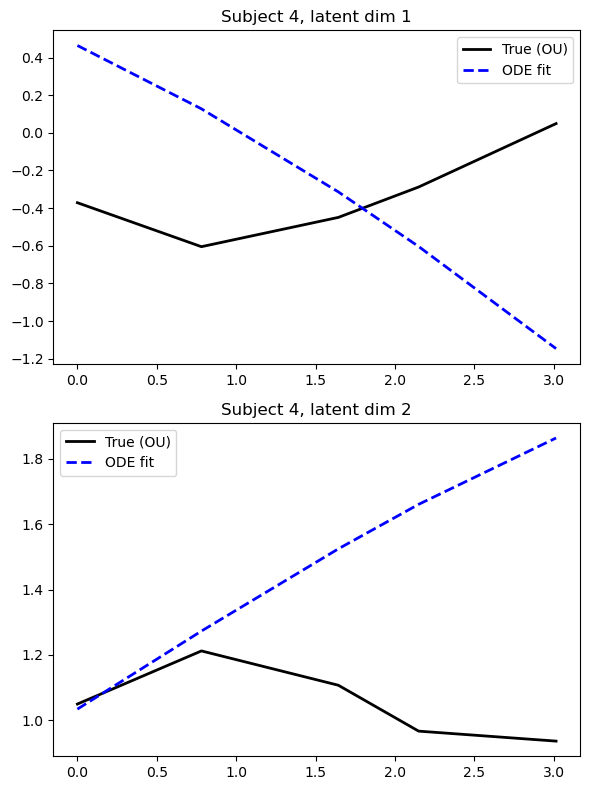

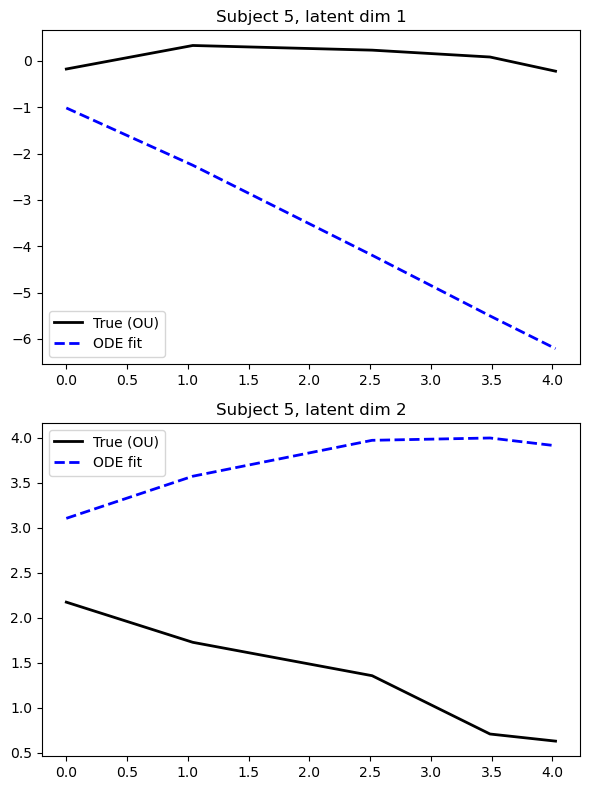

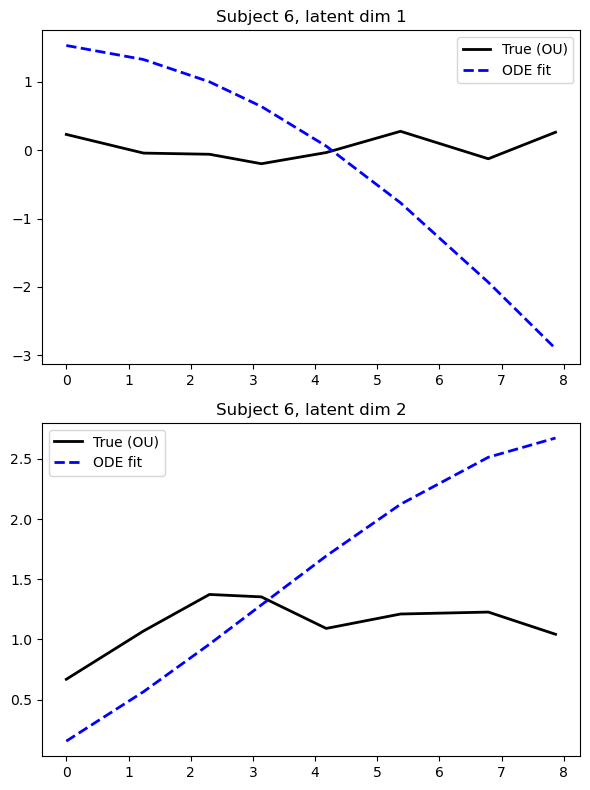

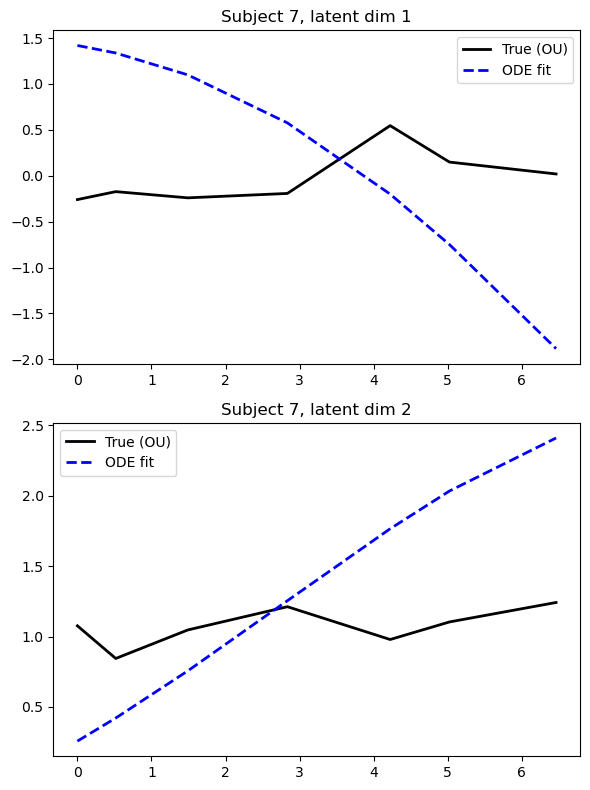

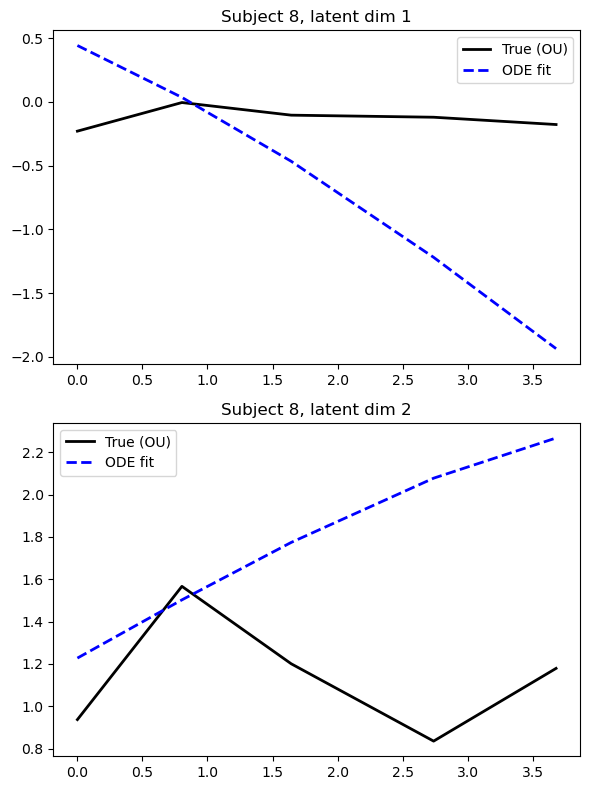

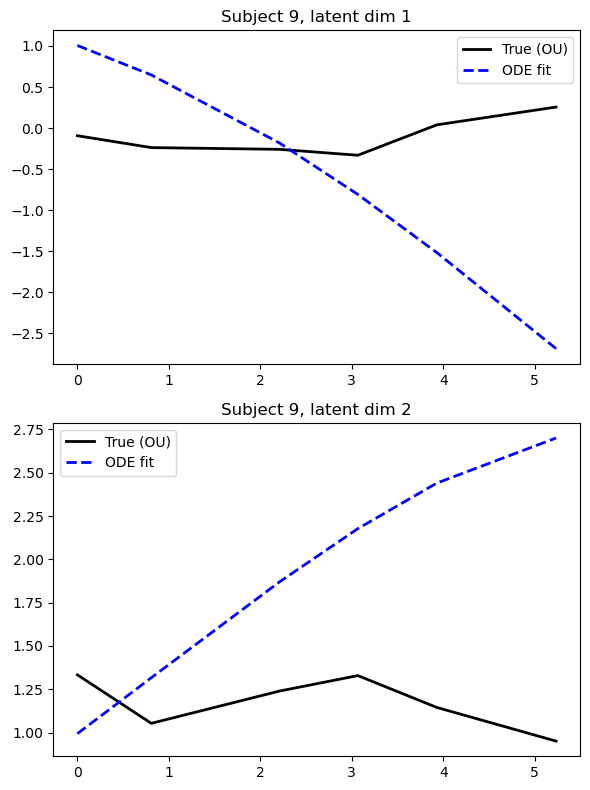

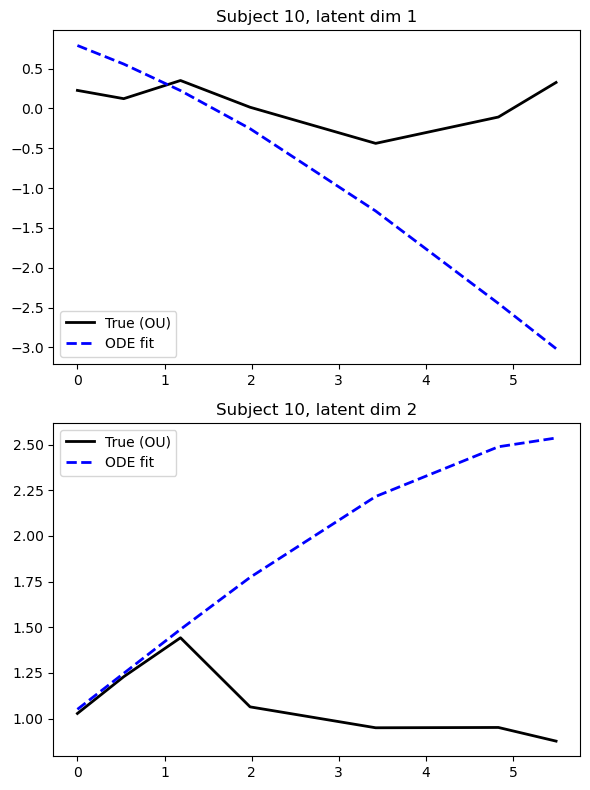

In [4]:
with torch.no_grad():
    for i in range(Nsub):
        f_est = model.latent_traj(model.f0[i], t_torch[i]).numpy()
        f_true = x_list[i]

        fig, axes = plt.subplots(K, 1, figsize=(6, 4*K))
        for k in range(K):
            axes[k].plot(t_list[i], f_true[:, k], 'k-', lw=2, label="True (OU)")
            axes[k].plot(t_list[i], f_est[:, k], 'b--', lw=2, label="ODE fit")
            axes[k].set_title(f"Subject {i+1}, latent dim {k+1}")
            axes[k].legend()
        plt.tight_layout()
        plt.show()


In [5]:
Theta_est = model.Theta.detach().numpy()
eigvals = np.linalg.eigvals(Theta_est)

print("Estimated Θ eigenvalues:", eigvals)
print("True OU mean-reversion rates:", -lambda_true)


Estimated Θ eigenvalues: [0.09744958+0.22253421j 0.09744958-0.22253421j]
True OU mean-reversion rates: [-0.5 -1. ]
